In [2]:
import numpy as np

# 1. Setup small corpus
corpus = [
    ["data", "science", "is", "fun"],
    ["data", "is", "power"]
]
vocab = ["data", "science", "is", "fun", "power"]

# 2. Create the TF Matrix (Rows=Docs, Cols=Vocab)
tf_matrix = np.array([
    [doc.count(word) / len(doc) for word in vocab] 
    for doc in corpus
])

# 3. Calculate IDF (Global)
N = len(corpus)
# Count how many docs contain each word
df = np.array([sum(1 for doc in corpus if word in doc) for word in vocab])
idf = np.log(N / df)

# 4. Final TF-IDF (Broadcasting multiplication)
tfidf_matrix = tf_matrix * idf

print("Vocabulary:", vocab)
print("TF-IDF Matrix:\n", tfidf_matrix)
print (f"tf matrix :{tf_matrix}")

Vocabulary: ['data', 'science', 'is', 'fun', 'power']
TF-IDF Matrix:
 [[0.         0.1732868  0.         0.1732868  0.        ]
 [0.         0.         0.         0.         0.23104906]]
tf matrix :[[0.25       0.25       0.25       0.25       0.        ]
 [0.33333333 0.         0.33333333 0.         0.33333333]]


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Example corpus
corpus = ["data science is fun.", "data is power."]

# Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Get feature names (vocabulary)
vocab = tfidf_vectorizer.get_feature_names_out()

# Convert the TF-IDF matrix  to a dense format and print
print("Vocabulary:", vocab)
print("TF-IDF Matrix:")
print(tfidf_matrix.toarray())

Vocabulary: ['data' 'fun' 'is' 'power' 'science']
TF-IDF Matrix:
[[0.40993715 0.57615236 0.40993715 0.         0.57615236]
 [0.50154891 0.         0.50154891 0.70490949 0.        ]]


In [5]:
import pandas as pd
import random

data = {
    "text": [
        "I am really worried about the recent market volatility and my portfolio performance.",
        "The onboarding process was seamless, thanks for the help.",
        "Can we schedule a call to discuss the management fees on my account?",
        "I’m very happy with the dividends we’ve seen this quarter.",
        "I need to update my beneficiary information on the life insurance policy.",
        # ... generate more variations here
    ],
    "category": ["negative", "positive", "negative", "positive", "neutral"] * 1  # Expand to 100+
}

df = pd.DataFrame(data)




In [6]:
from transformers import pipeline

# This will run efficiently on your CPU
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_sentiment(text):
    result = classifier(text)[0]
    return result['label'], result['score']

df['sentiment'], df['score'] = zip(*df['text'].apply(get_sentiment))




Loading weights: 100%|██████████████████████████████████████████████████████| 104/104 [00:00<00:00, 2212.30it/s]


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['text'])

from sklearn.linear_model import LogisticRegression
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'POSITIVE' else 0)
model = LogisticRegression()
model.fit(X, df['label'])

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]
top_10_positive = sorted(zip(feature_names, coefficients), key=lambda x: x[1], reverse=True)[:10]
top_10_negative = sorted(zip(feature_names, coefficients), key=lambda x: x[1])[:10]

# create wordcloud data with top 10 positive and negative words


# for word, __coef in zip(feature_names, coefficients):
#     print(f"{word}: {__coef:.4f}, {'positive' if __coef > 0 else 'negative'}")


print(f"\nTop 5 Positive Words: {top_10_positive}")
print(f"Top 5 Negative Words: {top_10_negative}")


account: -0.1076, negative
beneficiary: -0.0895, negative
beneficiary information: -0.0895, negative
discuss: -0.1076, negative
discuss management: -0.1076, negative
dividends: 0.1610, positive
dividends ve: 0.1610, positive
fees: -0.1076, negative
fees account: -0.1076, negative
happy: 0.1610, positive
happy dividends: 0.1610, positive
help: 0.1610, positive
information: -0.0895, negative
information life: -0.0895, negative
insurance: -0.0895, negative
insurance policy: -0.0895, negative
life: -0.0895, negative
life insurance: -0.0895, negative
management: -0.1076, negative
management fees: -0.1076, negative
market: -0.0895, negative
market volatility: -0.0895, negative
need: -0.0895, negative
need update: -0.0895, negative
onboarding: 0.1610, positive
onboarding process: 0.1610, positive
performance: -0.0895, negative
policy: -0.0895, negative
portfolio: -0.0895, negative
portfolio performance: -0.0895, negative
process: 0.1610, positive
process seamless: 0.1610, positive
quarter: 0.

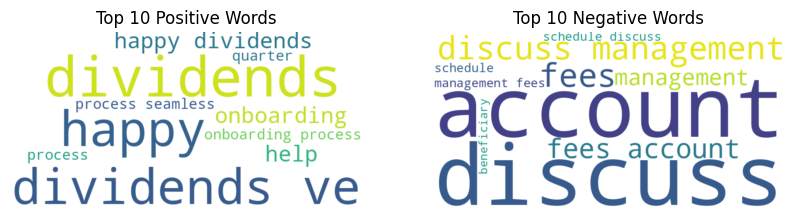

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create wordcloud data for top 10 positive and negative words
positive_wordcloud_data = {word: abs(coef) for word, coef in top_10_positive}
negative_wordcloud_data = {word: abs(coef) for word, coef in top_10_negative}

# Generate wordclouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(positive_wordcloud_data)
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(negative_wordcloud_data)

# Plot the wordclouds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Top 10 Positive Words")
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Top 10 Negative Words")
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis("off")

plt.show()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

# 1. Load the model and tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
embeddings = []
for text in df['text']:
    # 2. Prepare your text
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    # 3. Generate Embeddings (No gradient needed as we aren't training)
    with torch.no_grad():
        outputs = model(**inputs)

    # The 'last_hidden_state' contains the embeddings
    # Shape: [batch_size, sequence_length, hidden_size] (e.g., [1, 9, 768])
    last_hidden_states = outputs.last_hidden_state

    # 4. Perform Mean Pooling to get one vector for the sentence
    sentence_embedding = torch.mean(last_hidden_states, dim=1)
    embeddings.append(sentence_embedding)

    print(f"Embedding Shape: {sentence_embedding.shape}")
    print(f"First 5 values: {sentence_embedding[0][:5]}")

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['text'])

from sklearn.linear_model import LogisticRegression
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'POSITIVE' else 0)
model = LogisticRegression()
model.fit(X, df['label'])

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]
top_10_positive = sorted(zip(feature_names, coefficients), key=lambda x: x[1], reverse=True)[:10]
top_10_negative = sorted(zip(feature_names, coefficients), key=lambda x: x[1])[:10]

# create wordcloud data with top 10 positive and negative words


# for word, __coef in zip(feature_names, coefficients):
#     print(f"{word}: {__coef:.4f}, {'positive' if __coef > 0 else 'negative'}")


print(f"\nTop 5 Positive Words: {top_10_positive}")
print(f"Top 5 Negative Words: {top_10_negative}")



In [7]:
df.head()

,text,category,sentiment,score
0,I am really worried about the recent market vo...,negative,NEGATIVE,0.997869
1,"The onboarding process was seamless, thanks fo...",positive,POSITIVE,0.998742
2,Can we schedule a call to discuss the manageme...,negative,NEGATIVE,0.998746
3,I’m very happy with the dividends we’ve seen t...,positive,POSITIVE,0.999794
4,I need to update my beneficiary information on...,neutral,NEGATIVE,0.999018


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Sample Data
reviews = ["The food was great", "The food was terrible", "Great service", "Terrible service"]
labels = [1, 0, 1, 0] # 1=Pos, 0=Neg

# 1. TF-IDF Transformation
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(reviews)

# 2. Train a simple linear model
model = LogisticRegression()
model.fit(X, labels)

print("X", X.toarray())
print("Coefficients:", model.coef_)

# 3. Match words to their "Sentiment Weight"
words = vectorizer.get_feature_names_out()
print("Words:", words)
weights = model.coef_[0]

for word, weight in zip(words, weights):
    sentiment = "Positive" if weight > 0 else "Negative"
    print(f"Word: {word:10} | Weight: {weight:.4f} | Sentiment: {sentiment}")

X [[0.5        0.5        0.         0.         0.5        0.5       ]
 [0.5        0.         0.         0.5        0.5        0.5       ]
 [0.         0.70710678 0.70710678 0.         0.         0.        ]
 [0.         0.         0.70710678 0.70710678 0.         0.        ]]
Coefficients: [[-2.35911723e-17  5.08968850e-01  5.02469069e-18 -5.08968850e-01
  -2.35911723e-17 -2.35911723e-17]]
Words: ['food' 'great' 'service' 'terrible' 'the' 'was']
Word: food       | Weight: -0.0000 | Sentiment: Negative
Word: great      | Weight: 0.5090 | Sentiment: Positive
Word: service    | Weight: 0.0000 | Sentiment: Positive
Word: terrible   | Weight: -0.5090 | Sentiment: Negative
Word: the        | Weight: -0.0000 | Sentiment: Negative
Word: was        | Weight: -0.0000 | Sentiment: Negative
